# 色彩影像處理

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches
from matplotlib.colors import hsv_to_rgb, rgb_to_hsv

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("套件載入完成")

套件載入完成


## 加法與減法原色

### -加法RGB

1. 橙色 (Orange):


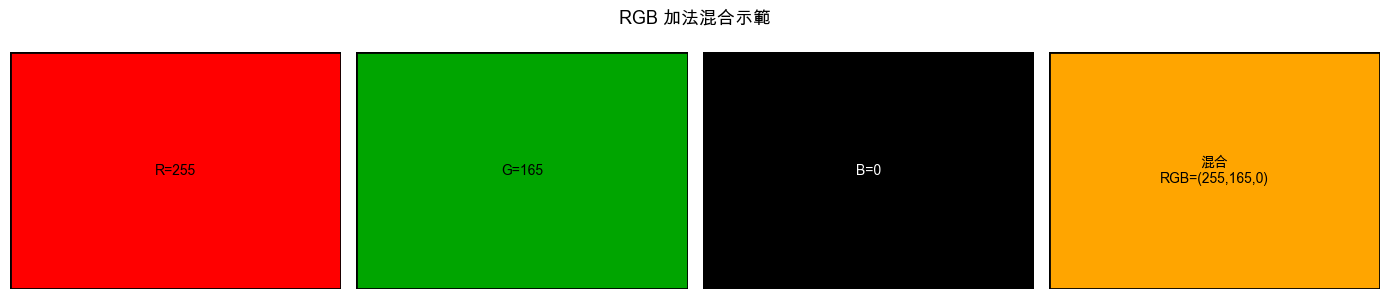


2. 紫色 (Purple):

3. 粉紅色 (Pink):


In [4]:
# 互動示範：RGB 色彩混合器
def show_rgb_mix(r, g, b):

    fig, axes = plt.subplots(1, 4, figsize=(14, 3))
    
    # 單色顯示
    colors = [
        ([r/255, 0, 0], f'R={r}'),
        ([0, g/255, 0], f'G={g}'),
        ([0, 0, b/255], f'B={b}'),
        ([r/255, g/255, b/255], f'混合\nRGB=({r},{g},{b})')
    ]
    
    for ax, (color, label) in zip(axes, colors):
        ax.add_patch(Rectangle((0, 0), 1, 1, facecolor=color, edgecolor='black', linewidth=2))
        text_color = 'white' if sum(color) < 0.5 else 'black'
        ax.text(0.5, 0.5, label, ha='center', va='center', 
               fontsize=10, fontweight='bold', color=text_color)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')
    
    plt.suptitle('RGB 加法混合示範', fontsize=13, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

print("1. 橙色 (Orange):")
show_rgb_mix(255, 165, 0)

#================================================= 練習1 =================================================
print("\n2. 紫色 (Purple):")
#試著調出紫色

print("\n3. 粉紅色 (Pink):")
#試著調出粉紅色

### -減法CYM/CYMK

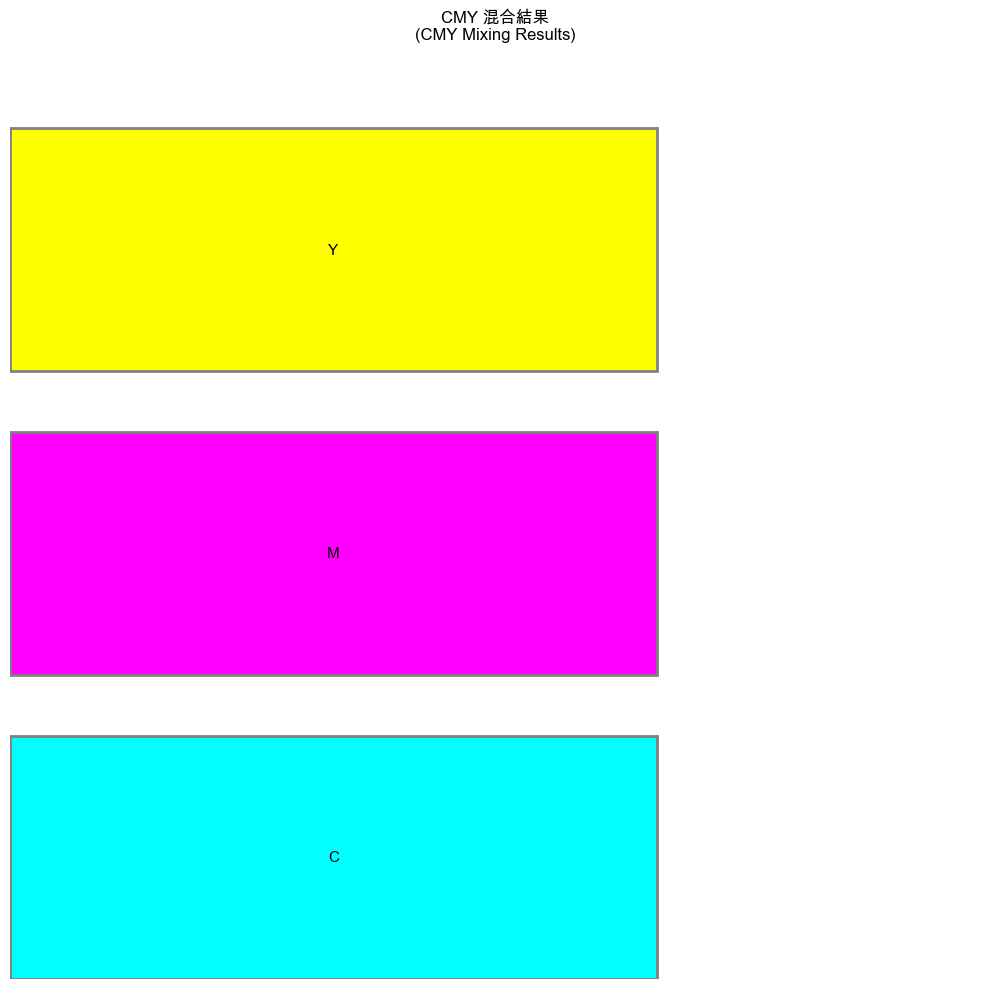

In [6]:
# 視覺化：CMY 減法混合
fig, ax2 = plt.subplots(figsize=(10, 10))
# 右圖：混合色彩範例
cmy_mixes = [
    ('C', [0, 1, 1]),
    ('M', [1, 0, 1]),
    ('Y', [1, 1, 0])
    #================================================= 練習2 =================================================
    # C+M
    # M+Y
    # Y+C
    # M+Y+C
]

for i, (label, color) in enumerate(cmy_mixes):
    y = i
    ax2.add_patch(Rectangle((0, y), 1, 0.8, facecolor=color, edgecolor='gray', linewidth=2))
    text_color = 'white' if sum(color) < 1.5 else 'black'
    ax2.text(0.5, y+0.4, label, ha='center', va='center', 
            fontsize=11, fontweight='bold', color=text_color)

ax2.set_xlim(0, 1.5)
ax2.set_ylim(0, len(cmy_mixes))
ax2.axis('off')
ax2.set_title('CMY 混合結果\n(CMY Mixing Results)', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## RGB與CMK互轉

### RGB -> CMK

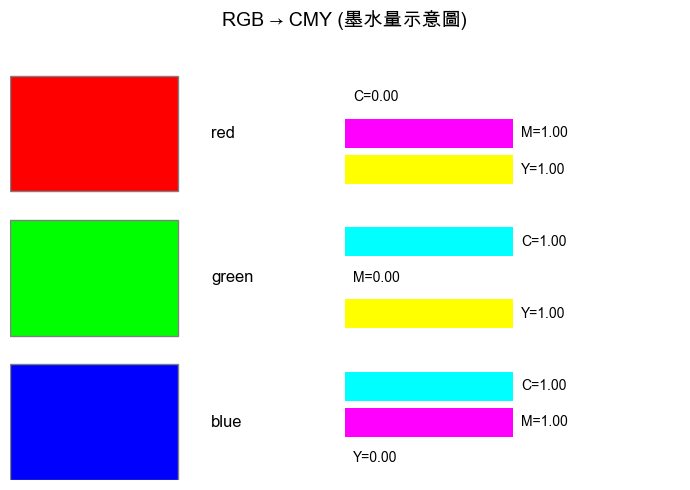

In [22]:
def rgb_to_cmy(r, g, b):
    c = 1 - r / 255.0
    m = 1 - g / 255.0
    y = 1 - b / 255.0
    return c, m, y

colors = [
    ("red", [255, 0, 0]),
    ("green", [0, 255, 0]),
    ("blue", [0, 0, 255])
]

fig, ax = plt.subplots(figsize=(7, 5))

for i, (label, rgb_val) in enumerate(colors):
    y = len(colors) - 1 - i

    # 正規化 RGB
    r, g, b = rgb_val
    rgb_norm = np.array(rgb_val) / 255.0

    # RGB → CMY
    c, m, yv = rgb_to_cmy(r, g, b)

    # 左欄顏色（RGB）
    ax.add_patch(Rectangle((0, y), 1, 0.8,
                           facecolor=rgb_norm,
                           edgecolor='gray'))

    # 中間顏色名稱
    ax.text(1.2, y + 0.4, label, va='center', fontsize=12)

    # 右側三條條形（C/M/Y）
    # C = 青色墨水
    ax.add_patch(Rectangle((2, y + 0.55), c, 0.2,
                           facecolor='cyan'))
    ax.text(2 + c + 0.05, y + 0.65, f"C={c:.2f}", va='center')

    # M = 洋紅墨水
    ax.add_patch(Rectangle((2, y + 0.30), m, 0.2,
                           facecolor='magenta'))
    ax.text(2 + m + 0.05, y + 0.40, f"M={m:.2f}", va='center')

    # Y = 黃色墨水
    ax.add_patch(Rectangle((2, y + 0.05), yv, 0.2,
                           facecolor='yellow'))
    ax.text(2 + yv + 0.05, y + 0.15, f"Y={yv:.2f}", va='center')

ax.set_xlim(0, 4)
ax.set_ylim(0, len(colors))
ax.axis('off')

ax.set_title("RGB → CMY (墨水量示意圖)", fontsize=14, pad=15)

plt.tight_layout()
plt.show()


### CMK -> RGB

Text(0.5, 1.0, 'CMY -> RGB')

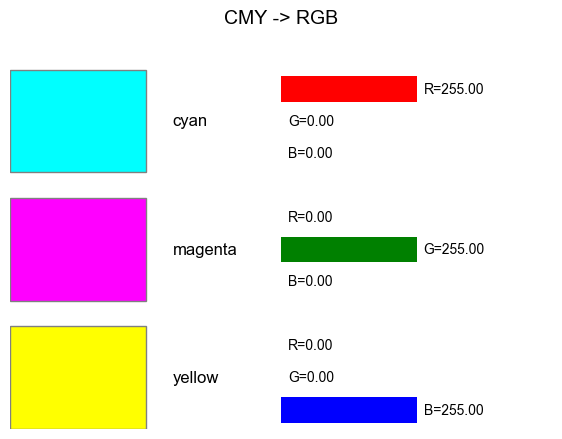

In [39]:
def cmy_to_rgb(c, m, vy):
    c /= 255.0
    m /= 255.0
    vy /= 255.0
    r = int((1 - c) * 255)
    g = int((1 - m) * 255)
    b = int((1 - vy) * 255)
    return r,g,b

colors = [
    ("cyan", [0, 255, 255]),
    ("magenta", [255, 0, 255]),
    ("yellow", [255, 255, 0]),
]

fig, ax = plt.subplots(figsize=(7,5))

for i, (label, cmy_val) in enumerate(colors):
    y = len(colors) - 1 - i

    c, m, vy = cmy_val
    cmy_norm = np.array([cmy_val]) / 255.0

    r,g,b = cmy_to_rgb(c,m,vy)

    ax.add_patch(Rectangle((0, y), 1, 0.8,
                            facecolor=cmy_norm,
                            edgecolor='gray'))
    ax.text(1.2, y+0.4, label, va='center', fontsize=12)

    ax.add_patch(Rectangle((2, y+0.55),r/255,0.2,facecolor='red'))
    ax.text(2 + r/255 +0.05, y+0.65, f"R={r:.2f}", va='center')

    ax.add_patch(Rectangle((2, y+0.30),g/255,0.2,facecolor='green'))
    ax.text(2 + g/255 +0.05, y+0.40, f"G={g:.2f}", va='center')

    ax.add_patch(Rectangle((2, y+0.05),b/255,0.2,facecolor='blue'))
    ax.text(2 + b/255 +0.05, y+0.15, f"B={b:.2f}", va='center')

ax.set_xlim(0, 4)
ax.set_ylim(0, len(colors))
ax.axis('off')

ax.set_title('CMY -> RGB', fontsize=14,pad=15)


## 使用hsv模型

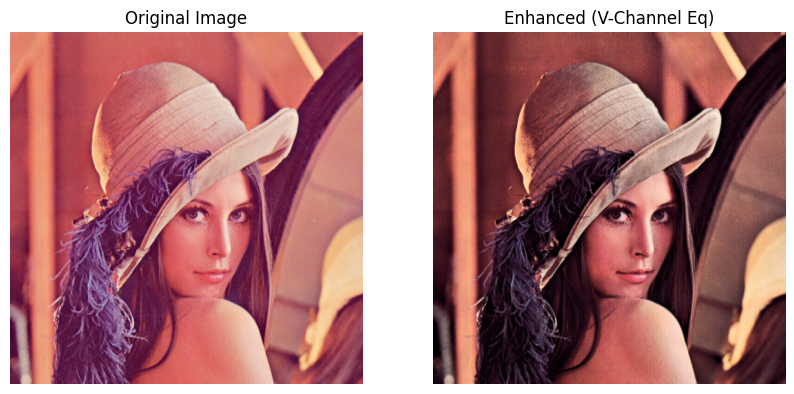

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def enhance_contrast_v_channel(image_path):
    # 1. 讀取影像
    img = cv2.imread(image_path)
    if img is None:
        print("找不到圖片，請確認路徑")
        return

    # 2. 轉為 HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # 3. 分離三個通道 (h, s, v)
    h, s, v = cv2.split(hsv)

    # 4. 只對 V (亮度) 通道做直方圖均衡化
    v_eq = cv2.equalizeHist(v)

    # 5. 合併回 HSV
    hsv_eq = cv2.merge([h, s, v_eq])

    # 6. 轉回 BGR 以便顯示或儲存
    result = cv2.cvtColor(hsv_eq, cv2.COLOR_HSV2BGR)

    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(img_rgb)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Enhanced (V-Channel Eq)")
    plt.imshow(result_rgb)
    plt.axis('off')
    
    plt.show()

enhance_contrast_v_channel('Lenna.png')

In [1]:
import cv2
import numpy as np

def vintage_filter(img):
    # 轉換到HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    h, s, v = cv2.split(hsv)
    
    # 1. 調整色相：整體偏向暖色調（黃褐色）
    # 將色相整體向黃色-橙色方向偏移
    h = (h + 10) % 180  # 輕微向暖色調偏移
    
    # 2. 降低飽和度
    s = s * 0.5  
    
    # 3. 調整明度：製造復古的柔和感
    v = v * 0.9  # 略微降低亮度
    v = np.clip(v + 15, 0, 255)  # 提升陰影部分
    
    # 合併通道  
    hsv_adjusted = cv2.merge([h, s, v]).astype(np.uint8)
    result = cv2.cvtColor(hsv_adjusted, cv2.COLOR_HSV2BGR)
    
    # 4. 添加褐色濾鏡效果（模擬老照片）
    sepia_kernel = np.array([[0.272, 0.534, 0.131],
                             [0.349, 0.686, 0.168],
                             [0.393, 0.769, 0.189]])
    
    sepia = cv2.transform(result, sepia_kernel)
    
    # 混合原圖和褐色效果
    result = cv2.addWeighted(result, 0.4, sepia, 0.6, 0)
    
    # 5. 添加輕微的顆粒感（噪點）
    noise = np.random.normal(0, 8, result.shape).astype(np.int16)
    result = np.clip(result.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    
    # 6. 降低對比度
    result = cv2.convertScaleAbs(result, alpha=0.9, beta=10)
    
    return result


def girly_filter(img):
    """
    少女風濾鏡
    特點：提高飽和度、偏粉紅色調、提高亮度、柔焦效果
    """
    # 轉換到HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    h, s, v = cv2.split(hsv)
    
    # 1. 調整色相：整體偏向粉紅/洋紅色調
    # 將色相向粉紅色方向偏移（在OpenCV中，粉紅色H值約為150-170）
    h = (h + 5) % 180  # 輕微向粉紅色偏移
    
    # 對於特定色相範圍，增強粉色效果
    # 紅色範圍 (0-10, 170-180)
    red_mask1 = (h >= 0) & (h <= 10)
    red_mask2 = (h >= 170) & (h <= 180)
    red_mask = red_mask1 | red_mask2
    h[red_mask] = (h[red_mask] + 165) % 180  # 紅色向粉色偏移
    
    # 2. 大幅提高飽和度：少女風色彩鮮豔
    s = s * 1.2  # 提高至140%
    s = np.clip(s, 0, 255)
    
    # 3. 提高明度：整體更明亮
    v = v * 1.15  # 提高亮度
    v = np.clip(v, 0, 255)
    
    # 合併通道
    hsv_adjusted = cv2.merge([h, s, v]).astype(np.uint8)
    result = cv2.cvtColor(hsv_adjusted, cv2.COLOR_HSV2BGR)
    
    # 4. 添加粉色濾鏡層
    pink_overlay = np.full(result.shape, (180, 150, 255), dtype=np.uint8)  # BGR格式的粉色
    result = cv2.addWeighted(result, 0.85, pink_overlay, 0.15, 0)
    
    # 5. 柔焦效果（高斯模糊+混合）
    blurred = cv2.GaussianBlur(result, (0, 0), 3)
    result = cv2.addWeighted(result, 0.7, blurred, 0.3, 0)
    
    # 6. 提高對比度和亮度
    result = cv2.convertScaleAbs(result, alpha=1.1, beta=15)
    
    # 7. 可選：添加輕微的發光效果（高光區域更亮）
    gray = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)
    _, highlight_mask = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
    highlight_mask = cv2.GaussianBlur(highlight_mask, (21, 21), 0)
    highlight_mask = cv2.cvtColor(highlight_mask, cv2.COLOR_GRAY2BGR) / 255.0
    
    glow = cv2.GaussianBlur(result, (0, 0), 10)
    result = (result * (1 - highlight_mask * 0.3) + glow * highlight_mask * 0.3).astype(np.uint8)
    
    return result


# 應用濾鏡
img = cv2.imread("Lenna.png", cv2.IMREAD_COLOR_RGB)
vintage = vintage_filter(img.copy())
girly = girly_filter(img.copy())

plt.figure(figsize=(10, 5))
    
plt.subplot(1, 2, 1)
plt.title("Vintage Image")
plt.imshow(vintage)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("girly image")
plt.imshow(girly)
plt.axis('off')

plt.show()


NameError: name 'plt' is not defined

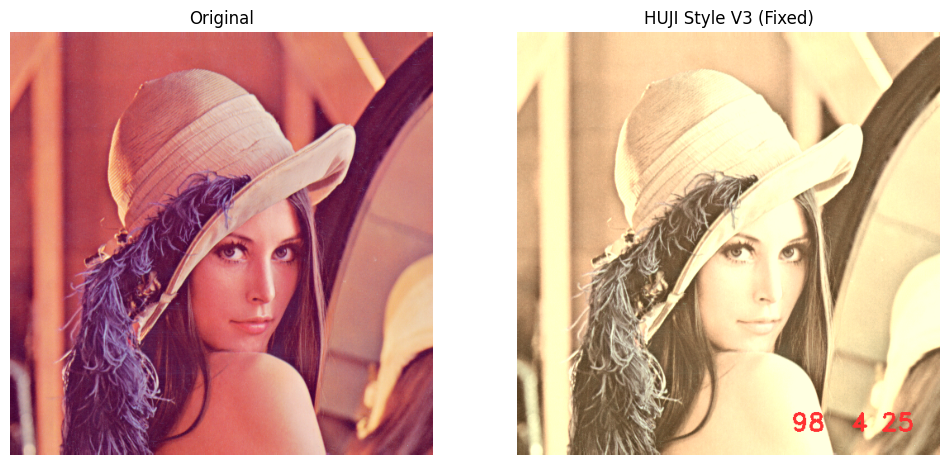

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def huji_filter_v3(img):
    # 複製圖像
    result = img.copy()
    
    # -----------------------
    # 1. 調整飽和度 (Saturation)
    # 轉到 HSV 空間調整，這比直接動 RGB 安全
    hsv = cv2.cvtColor(result, cv2.COLOR_BGR2HSV).astype(np.float32)
    h, s, v = cv2.split(hsv)

    s = s * 0.4
    s = np.clip(s, 0, 255)
    
    # 稍微提升亮度，營造閃光燈感
    v = v * 1.1
    v = np.clip(v, 0, 255)
    
    hsv = cv2.merge([h, s, v]).astype(np.uint8)
    result = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    result = cv2.convertScaleAbs(result, alpha=1.2, beta=-15)

    # -----------------------
    # 3. 色調調整 (Tint) - 關鍵修正
    # 不使用乘法，改用通道加減法，避免顏色爆掉
    b, g, r = cv2.split(result.astype(np.int16)) # 轉 int16 避免計算時溢位

    
    # 藍色：暗部提升(偏冷)，亮部稍微抑制(變黃)
    b = b - 30
    
    # 綠色：整體稍微提升 (富士底片感)
    g = g + 20
    
    # 紅色：整體提升 (暖感)
    r = r + 10
    
    # 合併並限制範圍在 0-255
    result_float = cv2.merge([b, g, r])
    result = np.clip(result_float, 0, 255).astype(np.uint8)

    # -----------------------
    # 4. 閃光燈暈影 (Vignette)
    # 製作中間亮、四周很暗的遮罩
    rows, cols = result.shape[:2]

        
    # -----------------------
    # 5. 添加日期水印 
    # 這裡僅作簡單模擬，畫上紅色日期
    cv2.putText(result, "98  4 25", (cols - 180, rows - 30), 
                cv2.FONT_HERSHEY_DUPLEX, 1.0, (50, 50, 255), 2)
    
    return result

img_path = "Lenna.png" 

try:
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError("找不到圖片")

    retro_v3 = huji_filter_v3(img)

    # 顯示
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    retro_rgb = cv2.cvtColor(retro_v3, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(img_rgb)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("HUJI Style V3 (Fixed)")
    plt.imshow(retro_rgb)
    plt.axis('off')

    plt.show()

except Exception as e:
    print(e)

In [ ]:
# ========================== 練習3 ==========================
# ===== 製作濾鏡 =====
# 1.可以使用上課學到的濾波操作些微模糊效果
# 2.影像銳化有助於改善對比度
# 3.hsv與rgb上的操作，可以改變色彩影像的不同面向
# 4.如果想做磨皮效果可以試看看雙邊濾波器